In [17]:
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd




In [18]:
data_dict = pickle.load(open('./data.pickle', 'rb'))


In [20]:
print(data_dict['data'][:1])



[[0.02984750270843506, 0.3363245129585266, 0.11642998456954956, 0.3108617067337036, 0.19383502006530762, 0.20388060808181763, 0.22241181135177612, 0.09254485368728638, 0.2114514708518982, 0.008071839809417725, 0.16141009330749512, 0.09155046939849854, 0.17308658361434937, 0.008406996726989746, 0.1564115285873413, 0.10226219892501831, 0.14442747831344604, 0.1560083031654358, 0.10835796594619751, 0.07783105969429016, 0.1182590126991272, 0.0, 0.10679304599761963, 0.11886045336723328, 0.10010367631912231, 0.16153469681739807, 0.05565977096557617, 0.08108332753181458, 0.05880904197692871, 0.026451796293258667, 0.055689096450805664, 0.13723498582839966, 0.053185105323791504, 0.1711282730102539, 0.0, 0.09131276607513428, 0.01078900694847107, 0.04421645402908325, 0.013401389122009277, 0.12216100096702576, 0.010196834802627563, 0.1502075493335724]]


In [21]:
data = np.asarray(data_dict['data'])
labels = np.asarray(data_dict['labels'])

In [29]:
x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, shuffle=True, stratify=labels)
model = RandomForestClassifier()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)

In [30]:
score = accuracy_score(y_predict, y_test)
print('{}% of samples phân loại đúng'.format(score * 100))


99.9034749034749% of samples phân loại đúng


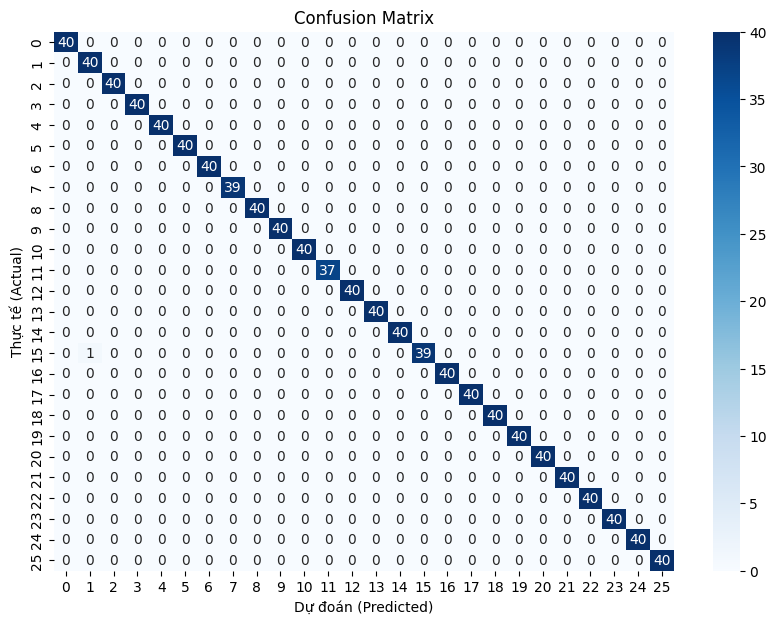

In [35]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.show()

In [37]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.98      1.00      0.99        40
          10       1.00      1.00      1.00        40
          11       1.00      1.00      1.00        40
          12       1.00      1.00      1.00        40
          13       1.00      1.00      1.00        40
          14       1.00      1.00      1.00        40
          15       1.00      1.00      1.00        39
          16       1.00      1.00      1.00        40
          17       1.00      1.00      1.00        40
          18       1.00      1.00      1.00        40
          19       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        40
          20       1.00      1.00      1.00        40
          21       1.00      1.00      1.00        40
          22       1.00      0.97      0.99        40
          23       1.00      1.00      1.00        40
          24       1.00    

In [8]:
f = open('model.p', 'wb')
pickle.dump({'model': model}, f)
f.close()